# Power calculations for a difference of means

---

#### Summary videos

- [Power calculations for a difference of two means](https://youtu.be/vnjjhQDedvs?si=eGg5yq5jgEGH7mzN) (9 minutes)
- [Determining an appropriate sample size](https://youtu.be/TFxx-hNvlQE?si=1DxIGzOP2eUJgodX) (3 minutes)

#### Walkthrough videos

- [Overview of the power of a test](https://drive.google.com/file/d/1VdBo2kYNJTZPB0L4Fjdvm-qCX7FN6yve/view?usp=sharing) (6 minutes)
- [Setting up a hypothesis test](https://drive.google.com/file/d/16Rnjs6HMSsg2ySB44OwTZJUE7Q6U6fDA/view?usp=sharing) (10 minutes)
- [Computing the power](https://drive.google.com/file/d/1A_m5ucXjGXwv_af1c87CsIkxX81nLsM0/view?usp=sharing) (9 minutes)
- [Determining the proper sample size](https://drive.google.com/file/d/1UvLlcubFzd8qmFyQX5XKZrJugGg_SVxm/view?usp=sharing) (11 minutes)
- [Exploring power visually](https://drive.google.com/file/d/1GkOEYLsz2eoXZHkRwOifY-UrqJrWihR2/view?usp=sharing) (6 minutes)

---

When planning a study or experiment, it is useful to know

> How likely is it that we will actually detect an effect that we're interested in via hypothesis testing?

This probability is called the **power** of the test and it can be computed depending on the **effect size** that we'd like to see.

## Setting up a hypothesis test

### Example 7.31

Suppose a pharmaceutical company has developed a new drug for lowering blood pressure, and they are preparing a clinical trial (experiment) to test the drug’s effectiveness. They recruit people who are taking a particular standard blood pressure medication. People in the control group will continue to take their current medication through generic-looking pills to ensure blinding.

Write down the hypotheses for a two-sided hypothesis test in this context.

#### Solution

- $H_0$: Neither drug is more effective than the other.
  $$\boxed{\mu_{T} - \mu_{C} = 0}$$
- $H_A$: One of the drugs is more effective than the other.
  $$ \mu_{T} - \mu_{C} \neq 0$$

### Example 7.32

The researchers would like to run the clinical trial on patients with systolic blood pressures between 140 and 180 mmHg. Suppose previously published studies suggest that the standard deviation of the
patients’ blood pressures will be about 12 mmHg and the distribution of patient blood pressures will be approximately symmetric.

If we had 100 patients per group, what would be the approximate
standard error for the difference of mean blood pressures between the two groups?

#### Solution

Note that we are assuming based off of previously collected data that

$$ s = 12 $$

for both the treatment and control group.

We find

$$ SE = \sqrt{\frac{12^2}{100} + \frac{12^2}{100}} \approx 1.70.$$

### Example 7.33

- What does the [null distribution](https://www.geogebra.org/classic#probability) for the difference of means look like?
- Does it matter if we use a $t$-distribution versus a normal distribution?

#### Solution

- The null distribution is normal, centered at $0$ with standard error approximately $1.70$.
- We can use a normal distribution in place of a $t$-distribution since the sample size is $100$ in both groups, resulting in the degrees of freedom being $99$ which is greater than or equal to $30$.

### Example 7.34

With $\alpha = 0.05$, for what values would we reject the null hypothesis? Use [GeoGebra](https://www.geogebra.org/classic#probability) to visualize the **rejection regions**.

#### Solution

With $\alpha = 0.05$, we have $z^* = 1.96$. This means we will reject the null hypothesis for Z-scores more than $1.96$ or less than $-1.96$.

- A Z-score of $1.96$ or more means that we have observed something $1.96$ standard errors above the mean on the null distribution. Since the null distribution is centered at $0$, this would correspond to observing a difference of
$$ 0 + 1.96 \times 1.70 = 3.332 \text{ mmHg}$$
or larger.
- Similarly, a Z-score of $-1.96$ or less corresponds to observing a difference of
$$ 0 - 1.96\times 1.70 = -3.332 \text{ mmHg}$$
or less.

## Computing the power

Suppose that the company researchers care about finding any effect on blood pressure that is 3 mmHg or larger than the standard medication. In this case, our **effect size** is 3 mmHg.

### Example 7.35

Suppose we decided to move forward with 100 patients per treatment group and the new drug
reduces blood pressure by an additional 3 mmHg relative to the standard medication.

What is the probability that we detect a drop? This is the **power** of the test.

#### Solution

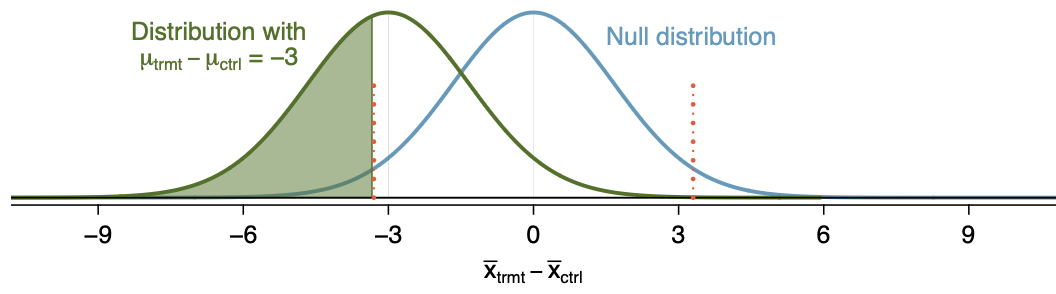

We would like to find the area shaded in green, which represents the probability that the observed difference in blood pressures is less than or equal to $-3.332$ on the *alternative distribution*.

The alternative distribution is centered at $-3$ and has the same standard error as the null distribution, namely $SE = 1.70$. We can find the Z-score for $-3.332$ on this distribution and use GeoGebra (or Python) to compute the desired probability.

$$Z = \frac{-3.332 - (-3)}{1.70} \approx -0.20.$$

Using GeoGebra: $$P(Z \leq -0.20) \approx 0.42.$$

## Determining the proper sample size

With 100 patients per group, the test is not very powerful!

### Example 7.36

Calculate the power to detect a change of $-3$ mmHg when using a sample size of 500 per group.
- Determine the standard error.
  - Recall, the sample standard deviation for patients was expected to be 12 mmHg.
- Identify the null distribution and rejection regions.
- Identify the alternative distribution when $\mu_T - \mu_C = -3$.
- Compute the probability that we reject the null hypothesis.

Run the code below to check your work.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import scipy.stats as stats
import pandas as pd

# Power of a difference of means, z-test
def power(standard_deviation_1, sample_size_1,
          standard_deviation_2, sample_size_2,
          null_value, significance_level, effect_size):
  standard_error = np.sqrt(
      standard_deviation_1**2/sample_size_1 +
      standard_deviation_2**2/sample_size_2
      )

  z_star = stats.norm.ppf(significance_level / 2)

  z_score = (abs(z_star * standard_error) - abs(effect_size))/standard_error

  power = 1 - stats.norm.cdf(z_score)

  return power

In [ ]:
print(power(12, 500, 12, 500, 0, 0.05, 3))

A sample using 500 patients per group is much more powerful, but could potentially be very expensive. There tend to eventually be diminishing returns in regard to the power of a test as sample size increases.

> Common practice is to identify a sample size that produces a power of 80%–90%.

### Example 7.37

What is the minimum sample size that will lead to a power of 80%? Use $\alpha = 0.05$.

#### Algebraic solution


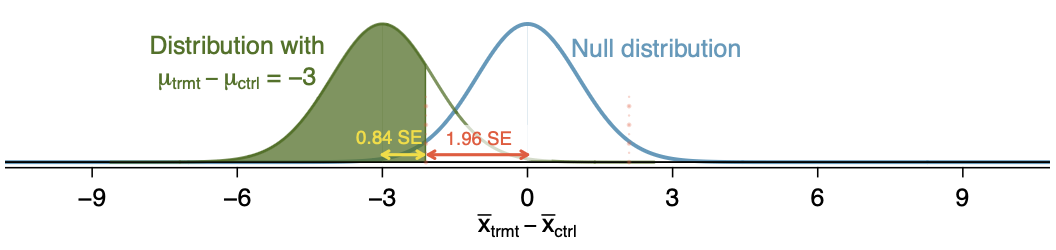



We know that in order to reject the null hypothesis, our observation must be 1.96 standard errors below (or above) the null value, which is $0$ in this case.

Meanwhile, to capture a power of $80\%$ requires a cutoff value that is 0.84 standard errors above the effect size. So, altogether, we find that

$$ 3 = 0.84 \times SE + 1.96 \times SE = 2.8 \times SE.$$

If we assign $n$ patients to each group, the standard error will be

$$\sqrt{\frac{12^2}{n} + \frac{12^2}{n}}$$

so we have

$$ 3 = 2.8 \times \sqrt{\frac{12^2}{n} + \frac{12^2}{n}}$$

which we can carefully solve for $n$ as follows.

$$\begin{align}
3 &= 2.8 \times \sqrt{\frac{12^2}{n} + \frac{12^2}{n}} \\
\frac{3}{2.8} &= \sqrt{\frac{12^2}{n} + \frac{12^2}{n}} \\
\left(\frac{3}{2.8}\right)^2 &= \frac{12^2}{n} + \frac{12^2}{n} \\
n \left(\frac{3}{2.8}\right)^2 & = 12^2 + 12^2 \\
n &= \frac{12^2 + 12^2}{\left(\frac{3}{2.8}\right)^2}\\
n &= 250.88.
\end{align}$$

Since $n$ has to be a number of people, we find that we need at least $251$ patients in each group to achive a power of $80\%$.

#### Numerical solution

In [ ]:
from plotnine import *

data = []
for n in range(1, 5000):
  data.append(power(12, n, 12, n, 0, 0.05, -3))
df = pd.DataFrame({'power': data})

(
    ggplot(df) +
    aes(x = range(1,5000), y = 'power') +
    geom_line() +
    geom_segment(x = 251, y = 0, xend = 251, yend = 0.8, color = 'red', linetype = 'dashed') +
    geom_hline(yintercept = 0.8, color = 'red', linetype = 'dashed') +
    labs(x = 'sample size')
)

Note that the plot suggests that sample sizes larger than 250–300 do not contribute much more to the power of the test in this case.

## A cartoon summary and visual exploration

Below is a cartoon summarizing the relationship between decision errors, significance level ($\alpha$), and the power of a hypothesis test.

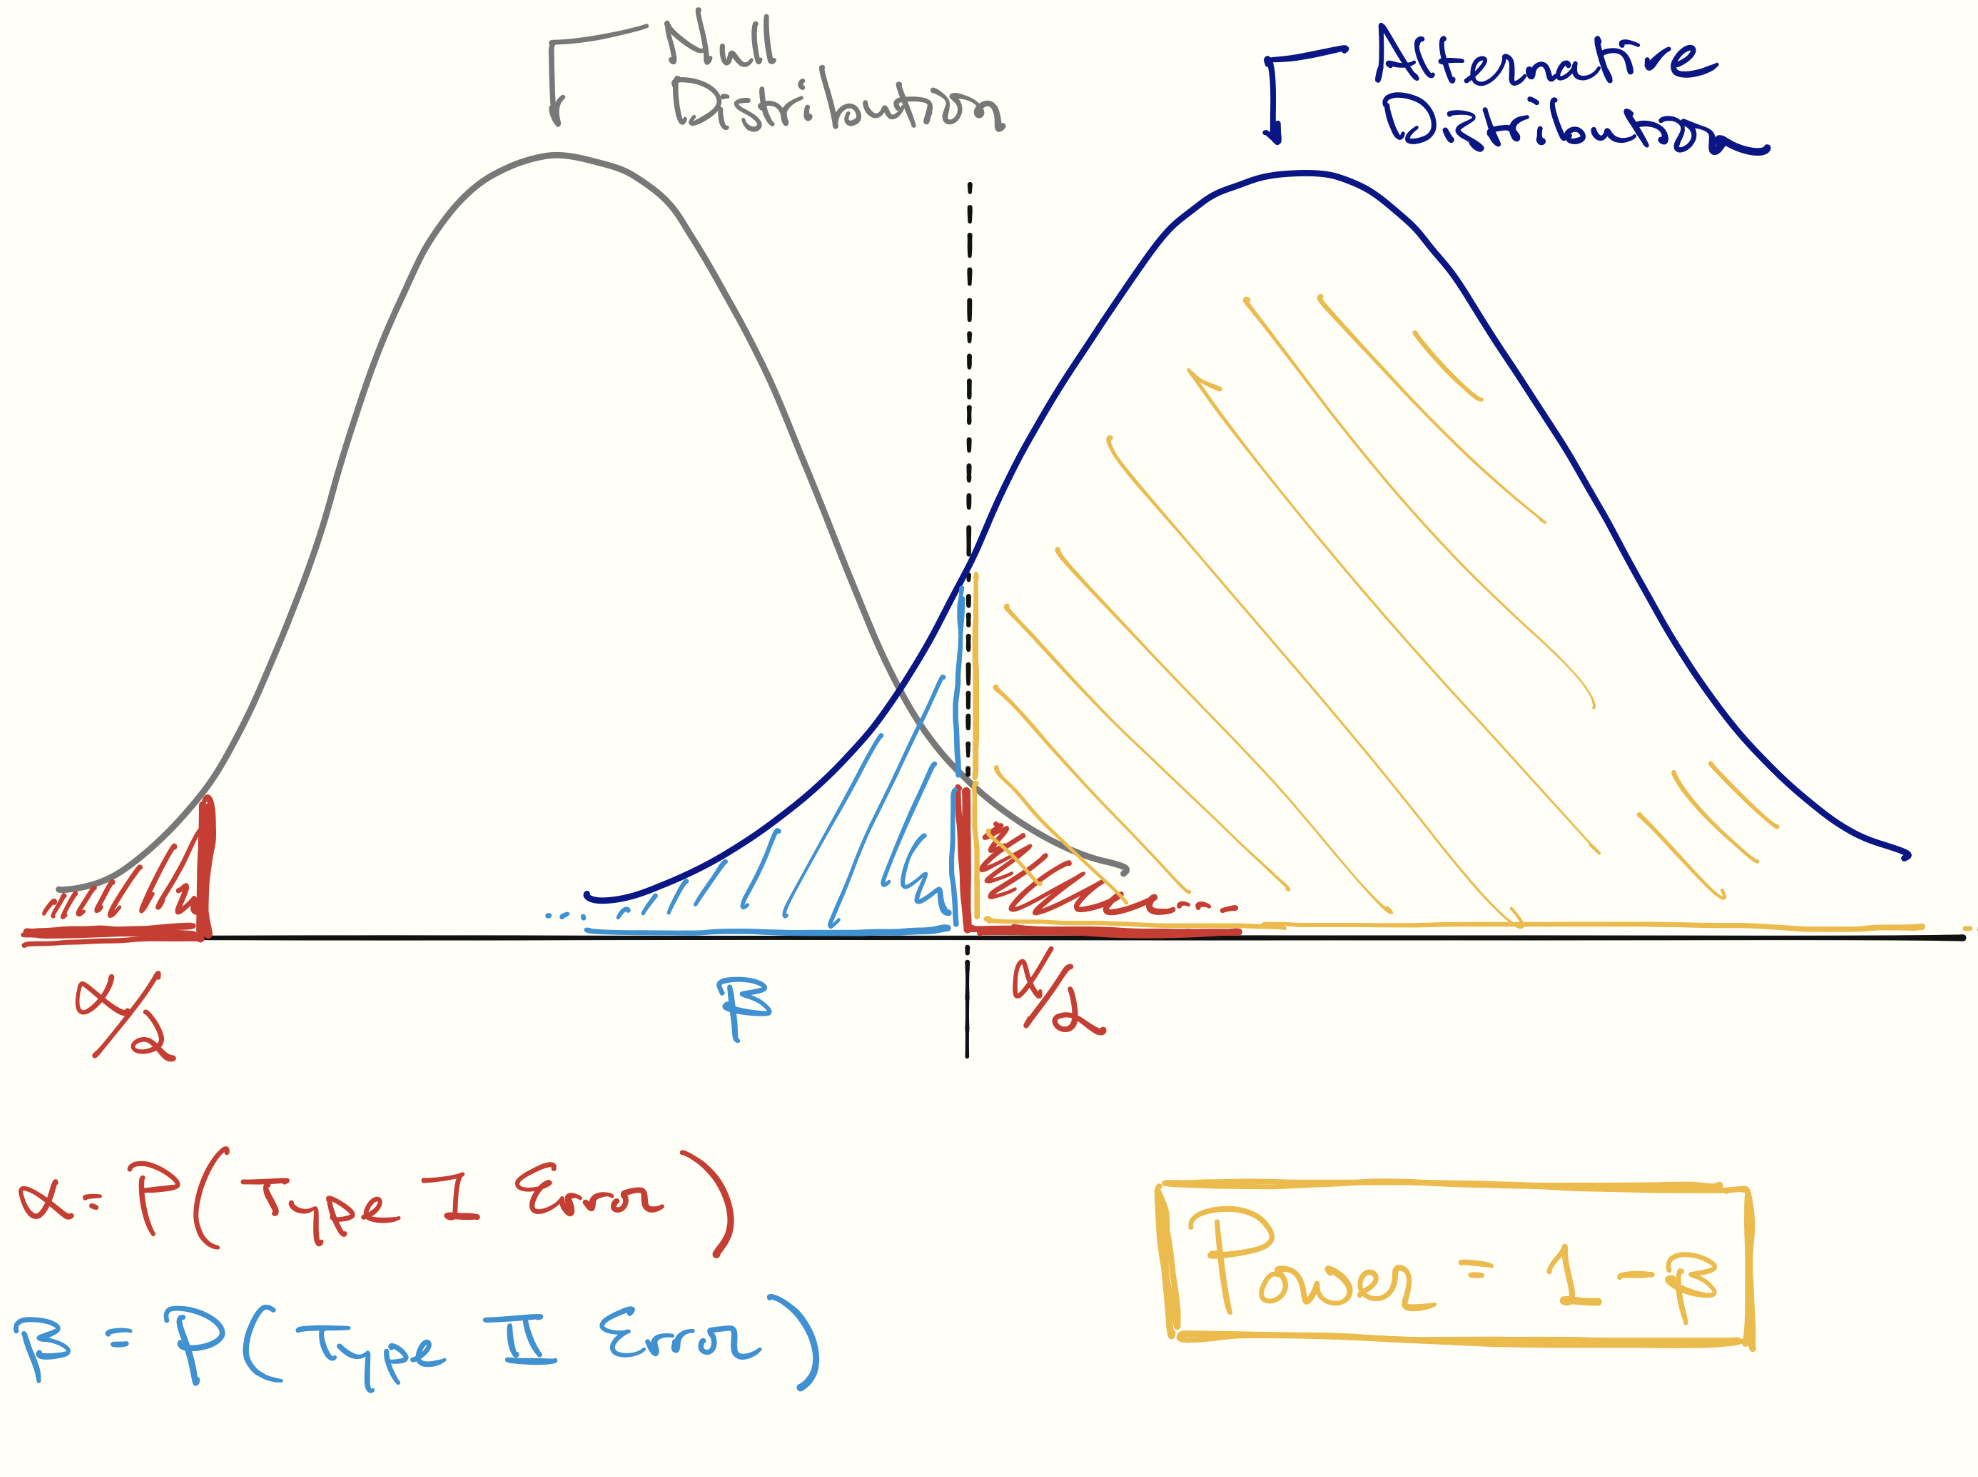

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import scipy.stats as stats
import pandas as pd
from plotnine import *
theme_set(theme_tufte())

# Power of a difference of means, z-test

def power(standard_deviation_1, sample_size_1,
          standard_deviation_2, sample_size_2,
          null_value, significance_level, effect_size):
  standard_error = np.sqrt(
      standard_deviation_1**2/sample_size_1 +
      standard_deviation_2**2/sample_size_2
      )

  z_star = stats.norm.ppf(significance_level / 2)

  z_score = (abs(z_star * standard_error) - abs(effect_size))/standard_error

  return [standard_error, z_star, z_score, 1 - stats.norm.cdf(z_score)]

In [ ]:
# Change the effect size, sample size, and significance level to see how the power changes.

effect_size = 3

sample_size = 100

significance_level = 0.05

power_result = power(12, sample_size, 12, sample_size,0, significance_level, effect_size)

print(f"Standard error: {power_result[0]}")
print(f"z_star: {abs(power_result[1])}")
print(f"Power: {power_result[3]}")

null_distribution = lambda x: stats.norm.pdf(x, loc = 0, scale = power_result[0])
alternative_distribution = lambda x: stats.norm.pdf(x, loc = effect_size, scale = power_result[0])

(
  ggplot(pd.DataFrame(data={"x": [-3.5, 6]}), aes(x="x")) +
  stat_function(fun=null_distribution, color = 'gray') +
  geom_vline(xintercept = [-power_result[1], power_result[1]], color = 'red', linetype = 'dashed') +
  stat_function(fun=alternative_distribution, color = 'blue') +
  ylab('') + xlab('')
)

---

This notebook was written by Timothy L. Clark, derivative of [OpenIntro Statistics by Diez, Çetinkaya-Rundel, and Barr](https://www.openintro.org/book/os/), released under [Creative Commons BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/deed.en) license.